      x          y
0  24.0  21.549452
1  50.0  47.464463
2  15.0  17.218656
3  38.0  36.586398
4  87.0  87.288984
    x          y
0  77  79.775152
1  21  23.177279
2  22  25.609262
3  20  17.857388
4  36  41.849864
y_pred 300 (300, 1)
[[ 7.57528866e+01]
 [ 2.06499325e+01]
 [ 2.16339138e+01]
 [ 1.96659512e+01]
 [ 3.54096524e+01]
 [ 1.47460446e+01]
 [ 6.09931668e+01]
 [ 9.34645504e+01]
 [ 1.96659512e+01]
 [ 4.90623136e+00]
 [ 3.92225004e+00]
 [ 1.86819699e+01]
 [ 9.44485317e+01]
 [ 6.09931668e+01]
 [ 3.54096524e+01]
 [ 1.47460446e+01]
 [ 6.39451107e+01]
 [ 1.37620633e+01]
 [ 8.55926998e+01]
 [ 6.78810360e+01]
 [ 8.75606625e+01]
 [ 5.01693722e+01]
 [ 8.75606625e+01]
 [ 2.65538205e+01]
 [ 9.54325131e+01]
 [ 5.70572415e+01]
 [ 7.77208493e+01]
 [ 2.06499325e+01]
 [ 9.14965878e+01]
 [ 2.65538205e+01]
 [ 9.74004757e+01]
 [ 3.04897458e+01]
 [ 3.24577084e+01]
 [ 7.87048306e+01]
 [ 2.75378018e+01]
 [ 4.62334469e+01]
 [ 5.21373349e+01]
 [ 6.78810360e+01]
 [ 2.75378018e+01]
 [ 3.24577084e+01]
 [ 8

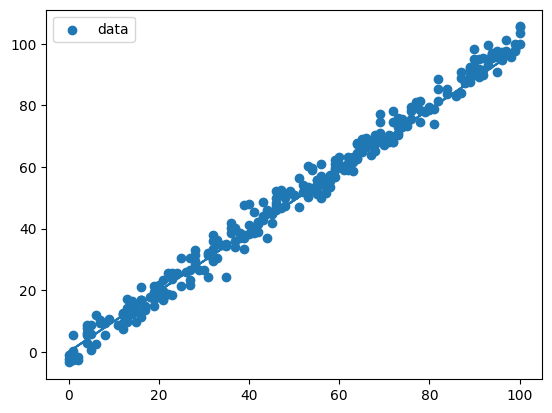

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from typing import Tuple, List
import sklearn.linear_model
from matplotlib.animation import FuncAnimation

# Download and read the data.
def read_train_data(filename: str) -> pd.DataFrame:
    df = pd.read_csv(filename)
    return df
pass

def read_test_data(filename: str) -> pd.DataFrame:
    df = pd.read_csv(filename)
    return df
pass


# Prepare your input data and labels
def prepare_data(df_train: pd.DataFrame, df_test: pd.DataFrame) -> tuple:
    train_data = df_train.dropna().drop(columns=['y']).to_numpy()
    train_label = df_train.dropna().drop(columns=['x']).to_numpy()

    test_data = df_test.dropna().drop(columns=['y']).to_numpy()
    test_label = df_test.dropna().drop(columns=['x']).to_numpy()

    return train_data, train_label, test_data, test_label
pass

# Implement LinearRegression class
class LinearRegression:   
    def __init__(self, learning_rate=0.01, epoches=1000):        
        self.learning_rate = learning_rate
        self.iterations    = epoches
        self.W = None
        self.b = None
          
    # Function for model training         
    def fit(self, X, Y):
        n_samples, n_features = X.shape
         # weight initialization
        self.W = np.zeros((n_features,1))
        self.b = 0
        
        for _ in range(self.iterations):
            error = 0
            for idx, x_i in enumerate(X):

                linear_output = np.dot(x_i, self.W) + self.b

                update = self.learning_rate * (Y[idx] - linear_output)
                
                self.W += update * x_i
                self.b += update

        return self.W, self.b

      
    # output      
    def predict(self, X):
        y_pred = np.zeros((X.size,1))
        print('y_pred',y_pred.size,y_pred.shape)
        #for i in range(X.size):
        y_pred = np.dot(X, self.W) + self.b
        #y_predictions = pd.DataFrame(y_pred).to_numpy()
        print(y_pred)
        return y_pred

# Calculate and print the mean square error of your prediction
def MSE(y_test, pred):
    squared_errors = (y_test - pred) ** 2

    # Calculate the mean squared error
    mse = np.mean(squared_errors)

    return mse



if __name__ == "__main__":
   
    data_path_train   = "./train2.csv"
    data_path_test    = "./test.csv"
    df_train, df_test = read_train_data(data_path_train), read_test_data(data_path_test)


    train_X, train_y, test_X, test_y = prepare_data(df_train, df_test)
    r = LinearRegression(learning_rate=0.0001, epoches=10)
    r.fit(train_X, train_y)

    print(df_train.head())
    print(df_test.head())

    # Make prediction with test set
    preds = r.predict(test_X)

    # Calculate and print the mean square error of your prediction
    mean_square_error = MSE(test_y, preds)
    print(mean_square_error) # I added this

    # plot your prediction and labels, you can save the plot and add in the report
    plt.scatter(test_X,test_y, label='data')
    plt.plot(test_X, preds)
    plt.legend()
    plt.show()

    
